In [28]:
import sys
import os

# Adds the parent directory to the search path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import xtrack as xt
import numpy as np
import matplotlib.pyplot  as plt
import matplotlib.patches as patches
import xpart as xp
import xobjects as xo
import math
from TuneDiagram.lib.TuneDiagram.tune_diagram import resonance_lines
from prettytable import PrettyTable
import xutil_DA_CC.xsuite_plot_functions as my_xpf
import xutil_DA_CC.xsuite_utilities as xutil
import constants
import my_functions as mf
from matplotlib.backends.backend_pdf import PdfPages
import tune_wp_scan as twps

In [ ]:
design=int(os.environ.get('DESIGN',1))
config=int(os.environ.get('CONFIG',1))
mode=os.environ.get('MODE','perfect')

In [29]:
pdf_run=True

if pdf_run is True:
    pdf = PdfPages(f"../Results/D{design}/C{config}/{mode}/AnalysisResults.pdf")

    _old_savefig = plt.savefig

    def _new_savefig(*args, **kwargs):
        pdf.savefig(plt.gcf())
        _old_savefig(*args, **kwargs)

    plt.savefig = _new_savefig

In [30]:
pdr= xt.Environment.from_json(f"JSON Files/D{design}/C{config}/pdr_{mode}.json")

ring=pdr.lines['ring']
print(ring.element_names)
period=pdr.lines['period']

variable_name = f"WP_D{design}"

current_wp = getattr(constants, variable_name)

Loading line from dict:   0%|          | 0/3144 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
['QFA_1RC', 'Drarc', 'Bend1_1R1', 'Drarc', 'QDA_1R1', 'Drarc', 'Bend2_1R1', 'Drarc', 'QFA_1R1', 'Drarc..1032', 'XF2arc2_1R1', 'Drarc..1034', 'Bend1_1R2', 'Drarc', 'QDA_1R2', 'Drarc..960', 'XD2arc_1R2', 'Drarc..962', 'Bend2_1R2', 'Drarc', 'QFA_1R2', 'Drarc', 'Bend1_1R3', 'Drarc', 'QDA_1R3', 'Drarc', 'Bend2_1R3', 'Drarc', 'QFA_1R3', 'Drarc', 'Bend1_1R4', 'Drarc', 'QDA_1R4', 'Drarc..963', 'XD2arc_1R4', 'Drarc..965', 'Bend2_1R4', 'Drarc', 'QFA_1R4', 'Drarc', 'Bend1_1R5', 'Drarc', 'QDA_1R5', 'Drarc', 'Bend2_1R5', 'Drarc', 'QFA_1R5', 'Drarc..996', 'XF2arc_1R5', 'Drarc..998', 'Bend1_1R6', 'Drarc', 'QDA_1R6', 'Drarc', 'Bend2_1R6', 'Drarc', 'QFA_1R6', 'Drarc', 'Bend1_1R7', 'Drarc', 'QDA_1R7', 'Drarc', 'Bend2_1R7', 'Drarc', 'QFA_M1R7', 'Drarc..1023', 'XF2arc_1R7', 'Drarc..1025', 'Bend1_1R8', 'Drarc', 'QDA_M1R8', 'Drarc', 'Bend2_1R8', 'Dra

In [31]:
E0 = constants.E0; VRF = constants.VRF

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )


ring.configure_radiation(model=None)
fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz

Slicing line:   0%|          | 0/174 [00:00<?, ?it/s]

In [32]:
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True )

In [33]:
print(ring.element_names)

('QFA_1RC', 'Drarc', 'Bend1_1R1', 'Drarc', 'QDA_1R1', 'Drarc', 'Bend2_1R1', 'Drarc', 'QFA_1R1', 'Drarc..1032', 'XF2arc2_1R1', 'Drarc..1034', 'Bend1_1R2', 'Drarc', 'QDA_1R2', 'Drarc..960', 'XD2arc_1R2', 'Drarc..962', 'Bend2_1R2', 'Drarc', 'QFA_1R2', 'Drarc', 'Bend1_1R3', 'Drarc', 'QDA_1R3', 'Drarc', 'Bend2_1R3', 'Drarc', 'QFA_1R3', 'Drarc', 'Bend1_1R4', 'Drarc', 'QDA_1R4', 'Drarc..963', 'XD2arc_1R4', 'Drarc..965', 'Bend2_1R4', 'Drarc', 'QFA_1R4', 'Drarc', 'Bend1_1R5', 'Drarc', 'QDA_1R5', 'Drarc', 'Bend2_1R5', 'Drarc', 'QFA_1R5', 'Drarc..996', 'XF2arc_1R5', 'Drarc..998', 'Bend1_1R6', 'Drarc', 'QDA_1R6', 'Drarc', 'Bend2_1R6', 'Drarc', 'QFA_1R6', 'Drarc', 'Bend1_1R7', 'Drarc', 'QDA_1R7', 'Drarc', 'Bend2_1R7', 'Drarc', 'QFA_M1R7', 'Drarc..1023', 'XF2arc_1R7', 'Drarc..1025', 'Bend1_1R8', 'Drarc', 'QDA_M1R8', 'Drarc', 'Bend2_1R8', 'DrarcS', 'QFDS_1R', 'DrDSL', 'QDDS_1R', 'Drarc', 'BendDS_1R', 'DrTrans', 'QFDoub_1R', 'DrDoub', 'QDDoub_1R', 'DrTripl..164', 'RFCav_1', 'DrTripl..166', 'QDTrip_1R1

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


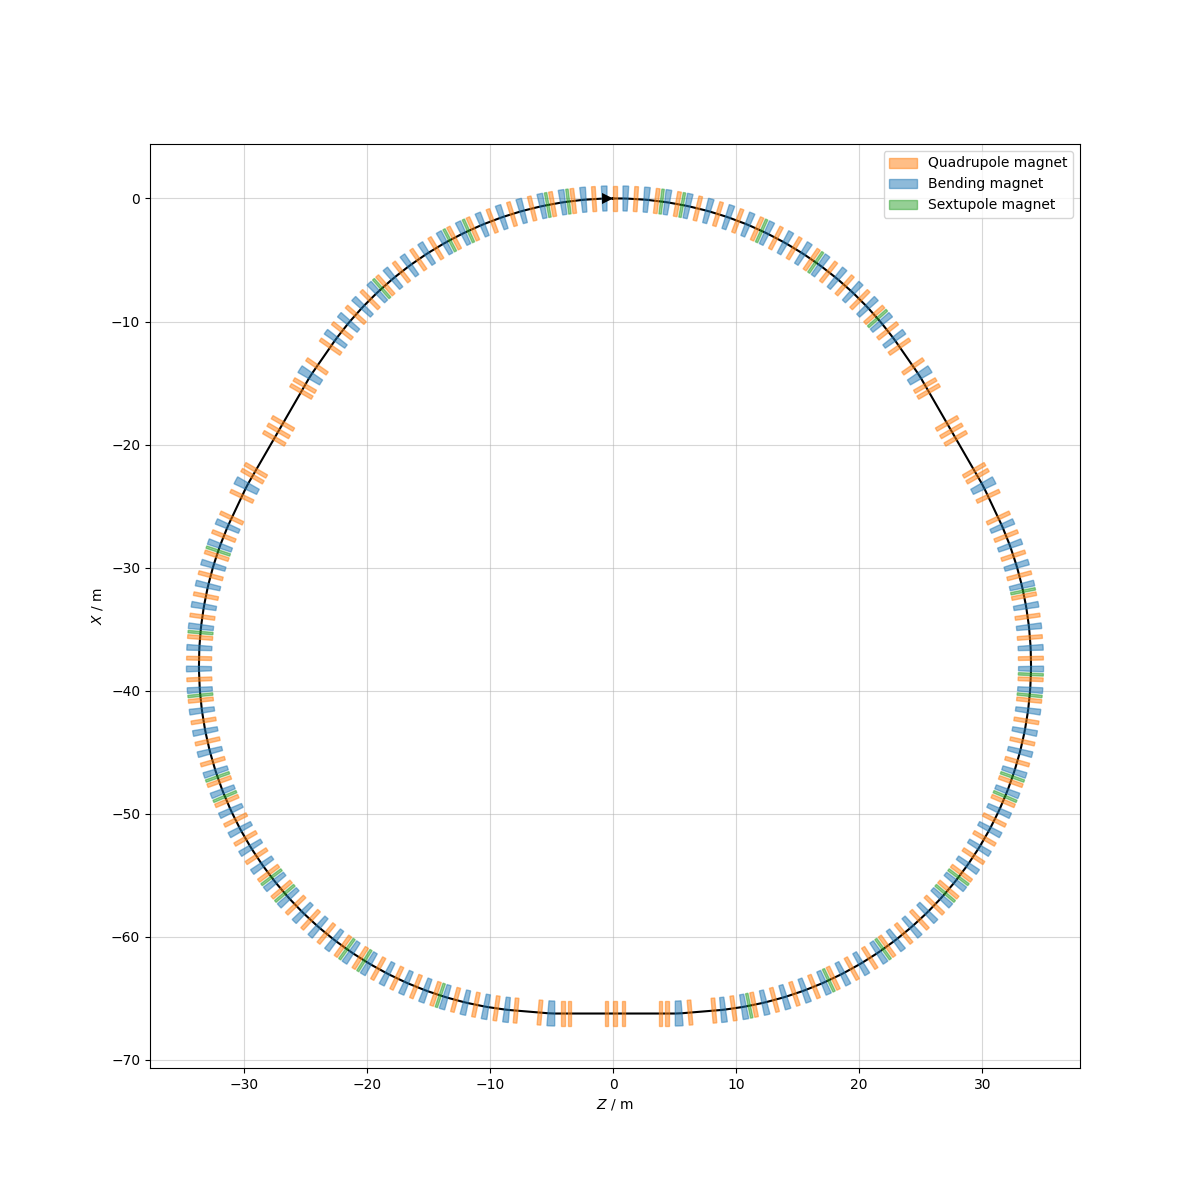

FileNotFoundError: [Errno 2] No such file or directory: '../Results/D1/C2/perfect/AnalysisResults.pdf'

In [34]:
#%matplotlib widget
#ring.survey().plot(labels=ring.element_names)
mf.survey_plot(ring)
#plt.tight_layout()
plt.savefig(f'Results/D{design}/C{config}/{mode}/ring_survey_{mode}.png')

In [ ]:
print(ring.element_names)

('QFA_1RC', 'Drarc0_1R0', 'SFA0_1R0', 'Drarc1_1R1', 'Bend1_1R1', 'Drarc2_1R1', 'QDA_1R1', 'Drarc3_1R1', 'SDA_1R1', 'Drarc4_1R1', 'Bend2_1R1', 'Drarc5_1R1', 'QFA_1R0', 'Drarc6_1R1', 'SFA_1R1', 'Drarc1_1R2', 'Bend1_1R2', 'Drarc2_1R2', 'QDA_1R2', 'Drarc3_1R2', 'SDA_1R2', 'Drarc4_1R2', 'Bend2_1R2', 'Drarc5_1R2', 'QFA_1R1', 'Drarc6_1R2', 'SFA_1R2', 'Drarc1_1R3', 'Bend1_1R3', 'Drarc2_1R3', 'QDA_1R3', 'Drarc3_1R3', 'SDA_1R3', 'Drarc4_1R3', 'Bend2_1R3', 'Drarc5_1R3', 'QFA_1R2', 'Drarc6_1R3', 'SFA_1R3', 'Drarc1_1R4', 'Bend1_1R4', 'Drarc2_1R4', 'QDA_1R4', 'Drarc3_1R4', 'SDA_1R4', 'Drarc4_1R4', 'Bend2_1R4', 'Drarc5_1R4', 'QFA_1R3', 'Drarc6_1R4', 'SFA_1R4', 'Drarc1_1R5', 'Bend1_1R5', 'Drarc2_1R5', 'QDA_1R5', 'Drarc3_1R5', 'SDA_1R5', 'Drarc4_1R5', 'Bend2_1R5', 'Drarc5_1R5', 'QFA_1R4', 'Drarc6_1R5', 'SFA_1R5', 'Drarc1_1R6', 'Bend1_1R6', 'Drarc2_1R6', 'QDA_1R6', 'Drarc3_1R6', 'SDA_1R6', 'Drarc4_1R6', 'Bend2_1R6', 'Drarc5_1R6', 'QFA_1R5', 'Drarc6_1R6', 'SFA_1R6', 'Drarc1_1R7', 'Bend1_1R7', 'Drarc2_1R7

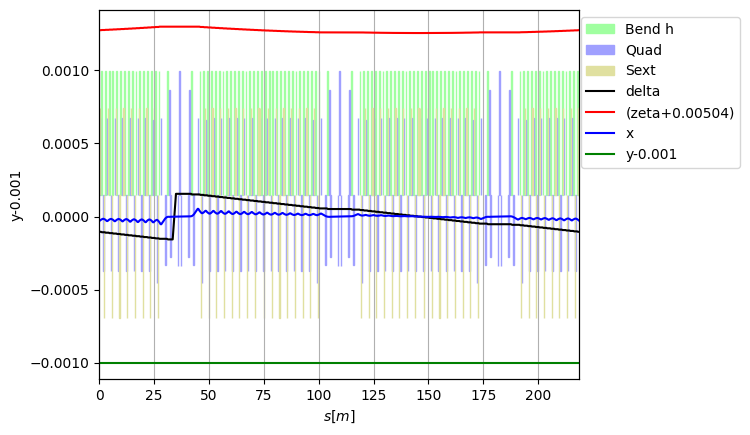

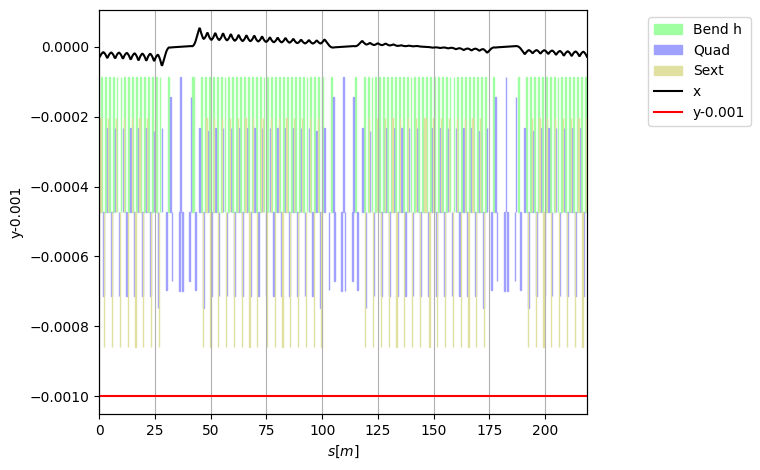

In [ ]:

ring_tw.plot(f'delta (zeta+0.00504) x y-0.001')
ring_tw.plot(f'x y-0.001')
plt.tight_layout()
plt.savefig(f'Results/D{design}/C{config}/{mode}/ring_closed_orbit_{mode}.png')


Initial Beta X: 5.4635 m
Initial Alpha X: -2.3668
Initial Beta Y: 1.1377 m
Initial Alpha Y: 0.6176
Initial Periodic Dispersion x:  0.274451 m
Initial Periodic Dispersion px: 0.120272
End Periodic Dispersion x:      0.274451 m
2nd order chrom x 63.70039935143889
2nd order chrom y 11.649608108696093


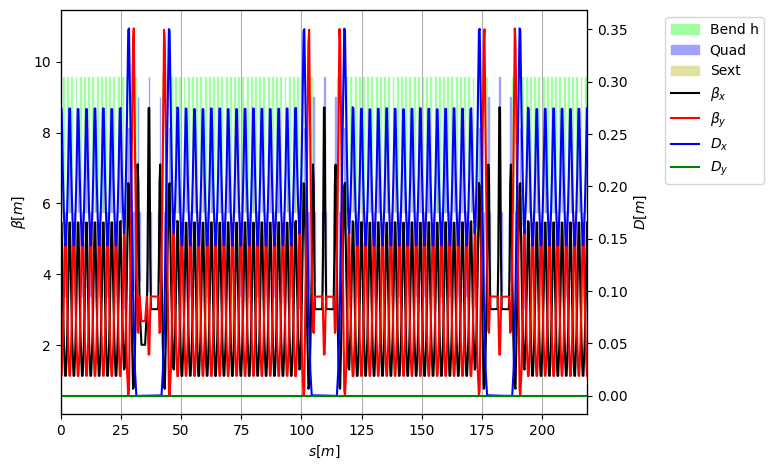

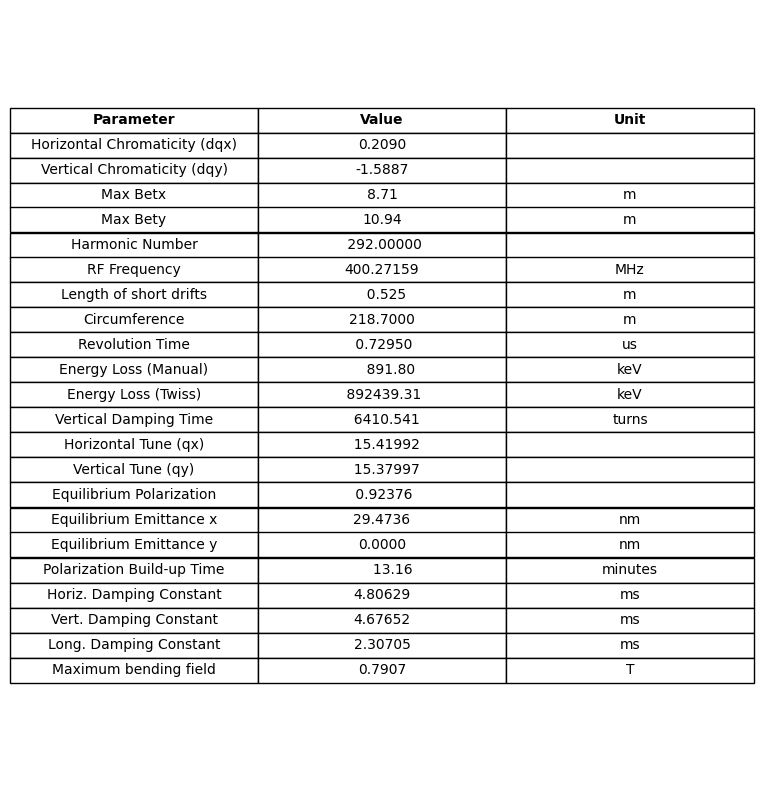

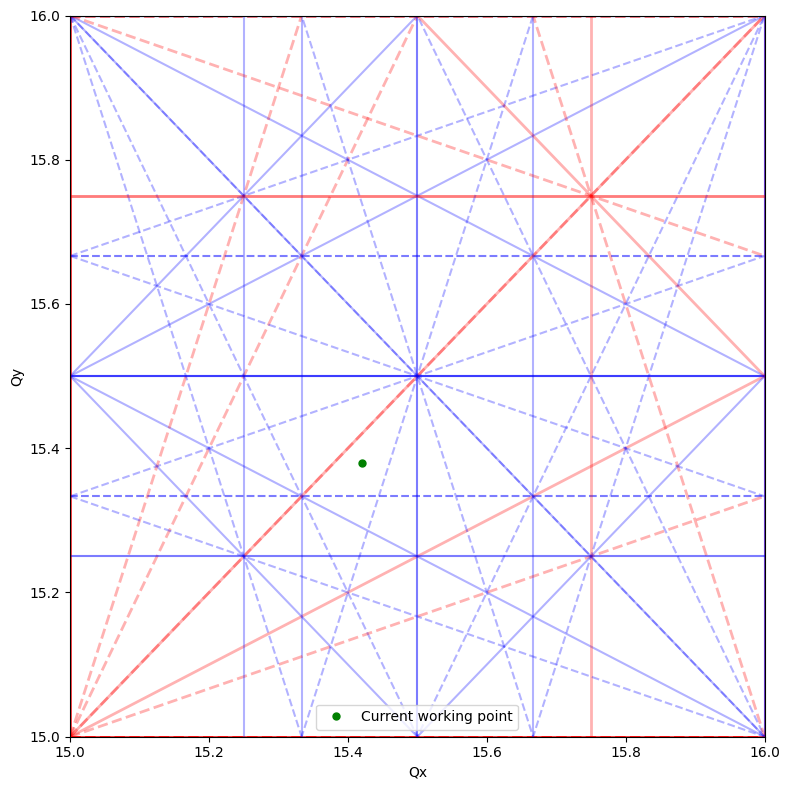

In [ ]:

ring_tw.plot()
plt.tight_layout()
plt.savefig(f'Results/D{design}/C{config}/{mode}/ring_twiss_{mode}.png')


def calc_damping_time_constant(m):
    num=2*E0*ring_tw.T_rev0
    den=ring_tw.partition_numbers[m]*U0
    tau=num/den
    return tau

# Initialize the table
brho = ring.particle_ref.p0c[0] / 299792458.0 
max_k0 = np.max(np.abs(ring_tw.k0l))
max_field_tesla = max_k0 * brho
# 1. Prepare your data in a list of lists
data = [
    ["Horizontal Chromaticity (dqx)", f"{ring_tw.dqx:.4f}", ""],
    ["Vertical Chromaticity (dqy)", f"{ring_tw.dqy:.4f}", ""],
    ["Max Betx", f"{max(ring_tw.betx):.2f}", "m"],
    ["Max Bety", f"{max(ring_tw.bety):.2f}", "m"],
    ["Harmonic Number", f"{fRF/fRev:10.5f}", ""],
    ["RF Frequency", f"{fRF*1e-6:8.5f}", "MHz"],
    ["Length of short drifts", f"{pdr['l_drift']:7.3f}", "m"],
    ["Circumference", f"{ring_tw.circumference:8.4f}", "m"],
    ["Revolution Time", f"{1e6*ring_tw.T_rev0:8.5f}", "us"],
    ["Energy Loss (Manual)", f"{U0*1e-3:10.2f}", "keV"],
    ["Energy Loss (Twiss)", f"{ring_tw.eneloss_turn:10.2f}", "keV"],
    ["Vertical Damping Time", f"{1/ring_tw.damping_constants_turns[1]:10.3f}", "turns"],
    ["Horizontal Tune (qx)", f"{ring_tw.qx:10.5f}", ""],
    ["Vertical Tune (qy)", f"{ring_tw.qy:10.5f}", ""],
    ["Equilibrium Polarization", f"{ring_tw.spin_polarization_eq:8.5f}", ""],
    ["Equilibrium Emittance x", f"{ring_tw.eq_gemitt_x * 1e9:.4f}", "nm"],
    ["Equilibrium Emittance y", f"{ring_tw.eq_gemitt_y * 1e9:.4f}", "nm"],
    ["Polarization Build-up Time", f"{(ring_tw.spin_t_pol_buildup_s)/60:10.2f}", "minutes"],
    ["Horiz. Damping Constant", f"{(1/ring_tw.damping_constants_s[0])*1e3:.5f}", "ms"],
    ["Vert. Damping Constant", f"{(1/ring_tw.damping_constants_s[1])*1e3:.5f}", "ms"],
    ["Long. Damping Constant", f"{(1/ring_tw.damping_constants_s[2])*1e3:.5f}", "ms"],
    ["Maximum bending field", f"{max_field_tesla:.4f}", "T"]
]

column_headers = ["Parameter", "Value", "Unit"]

betx0 = ring_tw.betx[0]
bety0 = ring_tw.bety[0]
alfx0 = ring_tw.alfx[0]
alfy0 = ring_tw.alfy[0]


print(f"Initial Beta X: {betx0:.4f} m")
print(f"Initial Alpha X: {alfx0:.4f}")
print(f"Initial Beta Y: {bety0:.4f} m")
print(f"Initial Alpha Y: {alfy0:.4f}")
dx_start = ring_tw.dx[0]
dpx_start = ring_tw.dpx[0]

print(f"Initial Periodic Dispersion x:  {dx_start:.6f} m")
print(f"Initial Periodic Dispersion px: {dpx_start:.6f}")

# To verify it is periodic, check the last element as well
dx_end = ring_tw.dx[-1]
print(f"End Periodic Dispersion x:      {dx_end:.6f} m")

# 2. Create the figure
fig, ax = plt.subplots(figsize=(8, 10)) # Adjust size to fit your rows
ax.axis('tight')
ax.axis('off')

# 3. Create the table
table = ax.table(
    cellText=data, 
    colLabels=column_headers, 
    cellLoc='center', 
    loc='center'
)

# 4. Optional: Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5) # Scale width and height of cells

# Bold the headers
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.savefig(f'Results/D{design}/C{config}/{mode}/table_{mode}.png')


#Working point plot
resonance_orders = (1,2,3,4)
Qx_range = (15,16)
Qy_range = (15,16)
resonances = resonance_lines(Qx_range,Qy_range,resonance_orders,3)
fig, ax = plt.subplots(1, figsize=(8,8), alpha=0.3)
ax.plot(ring_tw.qx, ring_tw.qy,'o', 
                color='green', label='Current working point', markersize=5)
ax.legend()
resonances.plot_resonance(fig)
plt.tight_layout()
plt.savefig(f'Results/D{design}/C{config}/{mode}/WP_{mode}.png')

print('2nd order chrom x', ring_tw.ddqx)
print('2nd order chrom y', ring_tw.ddqy)

'l_cell':   3.5000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5250,
'dl_drift':  -0.1500,
'l_doub':   0.2500,
'l_tripl':   3.0000,
'l_trips':   0.4000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.8579,
'kQDarc':  -2.8333,
'kQFarcM':   2.7695,
'kQDarcM':  -3.2635,
'kQFDS':   2.8577,
'kQDDS':  -2.6303,
'kQFDoub':   3.8961,
'kQDDoub':  -2.3330,
'kQFtr':   4.5752,
'kQDtr':  -2.6573,
'l_sext':   0.1000,
'kSF':  80.5236,
'kSD': -114.8259,
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_PRCH    Quadrupo  0.1500   0.0000   0.1500   0.0000  0.2125 'kQFarc' =  2.8579  
  SFA0_PR0    Sextupol  0.1000   0.3625   0.4625   0.2125  0.2125  None    =  0.0000  
  Bend1_PR1   Bend      0.4000   0.6750   1.0750   0.2125  0.5250  None    =  0.0000  
  QDA_PR1     Quadrupo  0.3000   1.6000   1.9000   0.5250  0.2125 'kQDarc' = -2.8333  
  SDA_PR1     Sextupol  0.1000   2.1125   2.2125   0.2125  0.2125  

<Axes: >

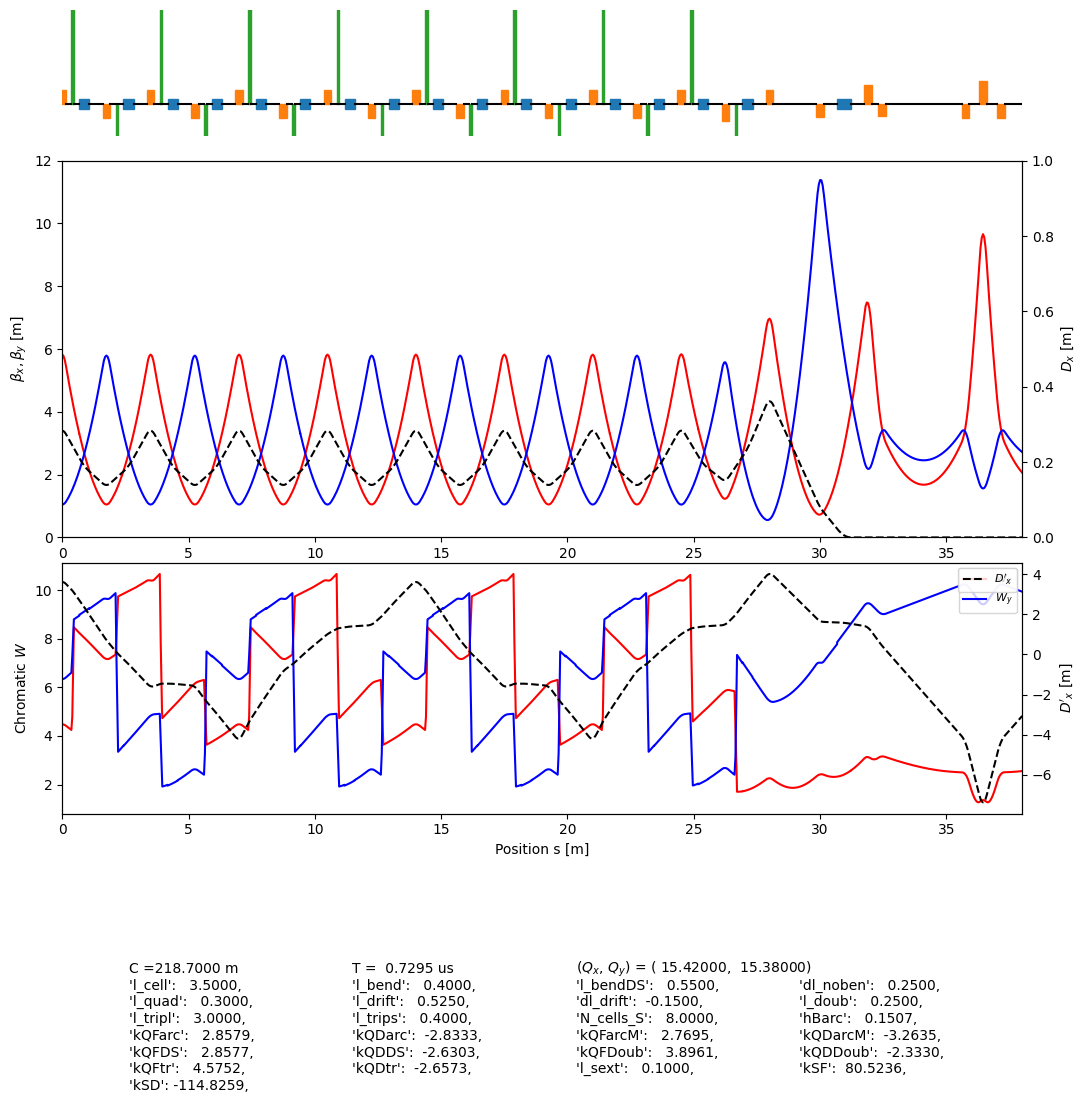

In [ ]:

mf.SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 12.), (0., 1.), .08,pdr, f"Results/D{design}/C{config}/{mode}/Standard.png" )

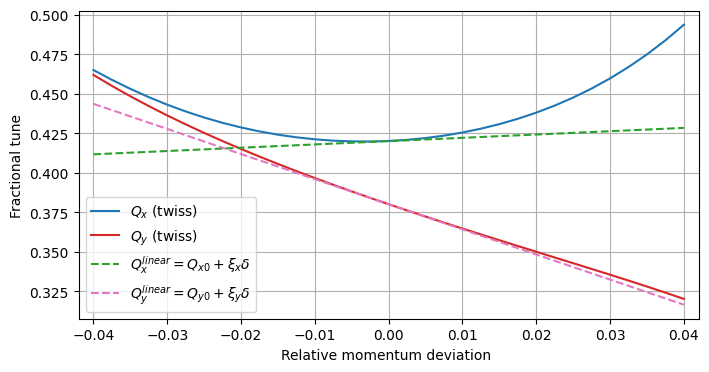

In [ ]:
max_dp = 4e-2
deltas = np.arange(-max_dp,max_dp+2.5e-3,2.5e-3)

delta=[]
qx=[]
qy=[]
qx_shift=[]
qy_shift=[]
for d in deltas:
    ring.configure_radiation(model=None)
    try:
        tw=ring.twiss4d(delta0=d)
        qx.append(tw.qx)
        qy.append(tw.qy)
        qx_s=ring_tw.qx+ring_tw.dqx*d
        qx_shift.append(qx_s)
        qy_s=ring_tw.qy+ring_tw.dqy*d
        qy_shift.append(qy_s)
        delta.append(d)
    except:
        print('deltap of %1.2e not stable'%d)


nominal_tw = ring.twiss4d(delta0=0)

plt.figure(figsize=(8,4))
WP = (nominal_tw.qx,nominal_tw.qy)
Qx_range = (np.floor(WP[0])-0.05,np.floor(WP[0])+0.55)
Qy_range = (np.floor(WP[1])-0.05,np.floor(WP[1])+0.55)

 
plt.plot(delta, qx-np.floor(WP[0]), label='$Q_x$ (twiss)', color='tab:blue')
plt.plot(delta, qy-np.floor(WP[1]), label='$Q_y$ (twiss)', color='tab:red')

# Dotted/Dashed lines for the linear model
plt.plot(delta, qx_shift-np.floor(WP[0]), '--', label=f'$Q_x^{{linear}} = Q_{{x0}} + \\xi_x \\delta$', color='tab:green')
plt.plot(delta, qy_shift-np.floor(WP[1]), '--', label=f'$Q_y^{{linear}} = Q_{{y0}} + \\xi_y \\delta$', color='tab:pink')
plt.xlabel('Relative momentum deviation ')
plt.ylabel('Fractional tune')
plt.legend()
plt.grid(True)
plt.xlim(-max_dp*1.05,max_dp*1.05)
plt.savefig(f'Results/D{design}/C{config}/{mode}/momentum_deviation{current_wp}_{mode}.png')

<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/tmp/mwatson/ipykernel_2158420/2499804786.py:38: SyntaxWarning: invalid escape sequence '\d'
  'ro', label='Nominal ($\delta=0$)', ms=9)


Tracking particles for footprint...
Done tracking.
Done computing footprint.
Successfully generated footprint for r_max = 16.0


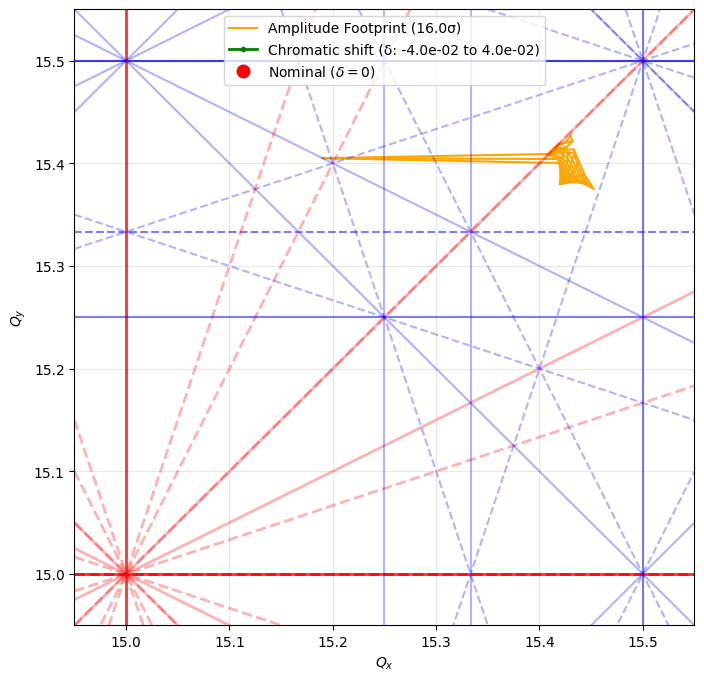

In [ ]:
r_max = 16.0
fp0 = None
nemitt_x = 1.3e-3
nemitt_y = 1.2e-3 

while r_max >= 1:
    try:
        n_r = int(r_max)
        fp0 = ring.get_footprint(
            nemitt_x=nemitt_x, 
            nemitt_y=nemitt_y, 
            r_range=(0.1, r_max), 
            n_r=n_r
        )
        print(f"Successfully generated footprint for r_max = {r_max}")
        break 
    except AssertionError:
        print(f"Particles lost at r_max = {r_max}. Reducing amplitude...")
        r_max -= 1.0

if fp0 is not None:
    resonances = resonance_lines(Qx_range, Qy_range, resonance_orders, 3)
    fig, ax = plt.subplots(figsize=(8,8))

    q_offset_x = np.floor(WP[0])
    q_offset_y = np.floor(WP[1])

    fp0.qx += q_offset_x
    fp0.qy += q_offset_y

    fp0.plot(ax=ax, color='orange', label=f'Amplitude Footprint ({r_max}σ)')

    ax.plot(qx + q_offset_x, qy + q_offset_y, '.-', 
            label=f'Chromatic shift (δ: {min(delta):.1e} to {max(delta):.1e})', 
            color='g', lw=2)

    ax.plot(nominal_tw.qx + q_offset_x, nominal_tw.qy + q_offset_y, 
            'ro', label='Nominal ($\delta=0$)', ms=9)

    resonances.plot_resonance(fig)

    ax.set_xlabel('$Q_x$')
    ax.set_ylabel('$Q_y$')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    plt.savefig(f'Results/D{design}/C{config}/{mode}/momentum_dev_working_point_{mode}.png')
    plt.show()
else:
    print("Could not generate a stable footprint even at 1 sigma.")

In [ ]:
tt=ring.get_table()
print(tt)

Table: 651 rows, 11 cols
name                   s element_type isthick isreplica parent_name iscollective       s_start ...
QFA_1RC                0 Quadrupole      True     False None               False             0
Drarc0_1R0           0.3 Drift           True     False None               False           0.3
SFA0_1R0          0.5125 Sextupole       True     False None               False        0.5125
Drarc1_1R1        0.6125 Drift           True     False None               False        0.6125
Bend1_1R1          0.825 Bend            True     False None               False         0.825
Drarc2_1R1         1.225 Drift           True     False None               False         1.225
QDA_1R1             1.75 Quadrupole      True     False None               False          1.75
Drarc3_1R1          2.05 Drift           True     False None               False          2.05
SDA_1R1           2.2625 Sextupole       True     False None               False        2.2625
Drarc4_1R1        2.3

Current Operating Tunes -> Qx: 15.4200, Qy: 15.3800
Identified Structural Superperiodicity (N_c): 3

=== VERDIER RESONANCE FILTER RESULTS ===
 Order  m  n  Global Harmonic (k) Distance to Resonance              Verdier Status Resonance Condition
     5 -2 -3                  -77                0.0200 Suppressed (Non-Structural) -2*Qx + -3*Qy = -77
     5  2  3                   77                0.0200 Suppressed (Non-Structural)    2*Qx + 3*Qy = 77
Detected Superperiodicity N_c = 3
Analyzing explicit resonance orders: (1, 2, 3, 4, 5)


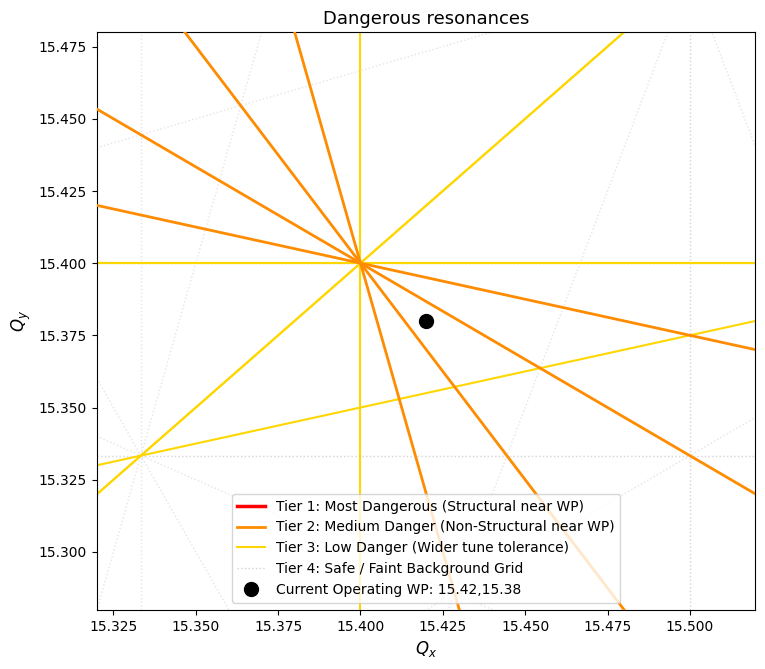

In [ ]:


try:
   
    res_df = twps.analyse_verdier_resonances_from_line(
        ring, max_order=5, tune_tolerance=0.02
    )

    if res_df is not None and not res_df.empty:
        print("\n=== VERDIER RESONANCE FILTER RESULTS ===")
        print(res_df.to_string(index=False))
    else:
        print("\nNo dangerous resonance lines found within the specified tune tolerance.")
except NameError:
    print(
        "Please check the name of your Xtrack Line variable inside your workspace cell."
    )


twps.plot_dangerous_resonances(ring, ring_tw.qx, ring_tw.qy, max_order=(1,2,3,4,5), tune_range=0.1)
plt.savefig(f'Results/D{design}/C{config}/{mode}/dangerous_resonances_{mode}.png')

In [ ]:

line=ring
line.config.XTRACK_USE_EXACT_DRIFTS = True
xutil.set_integrator (line)
particle = 'positron'
operation_mode = 'z'
modes = {'z': 45.6e9, # in eV 
        'w': 80e9, # in eV
        'h': 120e9, # in eV 
        't': 182.5e9 # in eV
        }
energy = modes[operation_mode]
parameters = xutil.log_parameters (None, operation_mode, particle_type=particle, modes=modes)
# ## Choose a context
context = xo.ContextCpu()         # For CPU
context_tracking = xo.ContextCpu(omp_num_threads='auto') # For CPU with activate multi-core CPU parallelization


# ## Transfer lattice on context and compile tracking code
# line.build_tracker(_context=context)

# line.configure_radiation(model='mean')
# line.compensate_radiation_energy_loss()

tw = line.twiss(eneloss_and_damping=True)

#xutil.update_reference_parameters_from_line (line, parameters, BS_scale_factor=0, update_type='all', max_bb_param=0)
# xutil.correct_parameters_conflicts(parameters, update_study_parameters_from_reference=False)

gamma0 = ring.particle_ref.gamma0[0]
beta0 = ring.particle_ref.beta0[0]

n_emittancex = 1.354177116369456e-6 * gamma0 * beta0
n_emittancey = 1.420755089827341e-6 * gamma0 * beta0

parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_DA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 1000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':n_emittancex,
    'ini_cond_nemittance_y': n_emittancey,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}




## Initial conditions
#particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)
particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])

line.discard_tracker()
line.build_tracker(_context=context_tracking)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


The line already has an associated tracker


Tracking:   0%|          | 0/2500 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


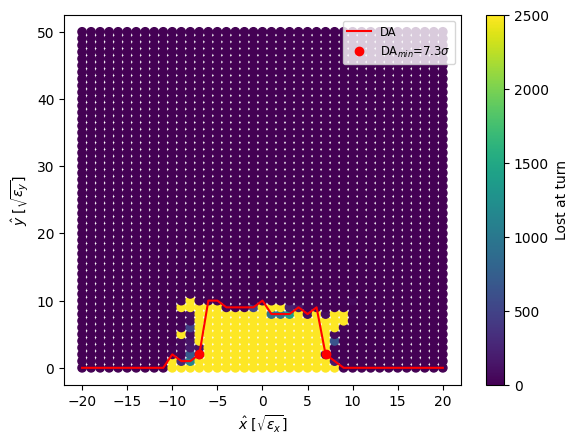

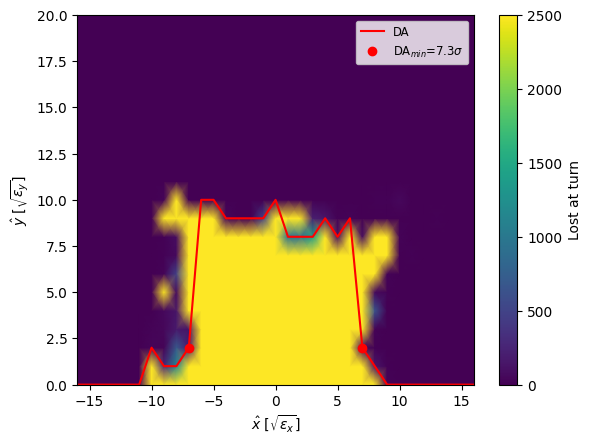

In [ ]:
line.discard_tracker()
## Tracking studies
line.configure_radiation(model='mean')


## Change context for multy CPU for tracking

line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)

# dic_particles_all = xutil.tracking_data_process (tracking_data=line.record_last_track, 
#                             monitor_twiss=ring_tw.rows[0], 
#                             norm_emit_x=parameters['reference_parameters']['normalized_emittance_x'],
#                             norm_emit_y=parameters['reference_parameters']['normalized_emittance_y'],
#                             sigma_z=parameters['reference_parameters']['bunch_length'], 
#                             sigma_delta=parameters['reference_parameters']['energy_spread'],
#                             particle_id_to_use='all')
# xutil.save_dict_to_h5(f'{output_dir}/dic_particles_all.h5', dic_particles_all)


# liftime = my_xpf.particle_population_vs_turns (dic_particles_all['state'], T_rev0=tw.T_rev0)
# my_xpf.phase_space_evolution_difference (dic_particles_all['zeta'][:,0], dic_particles_all['delta'][:,0], dic_particles_all['zeta'][:,-1], dic_particles_all['delta'][:,-1], x_axis_label=r'$z~[m]$', y_axis_label=r'$\delta$')
# my_xpf.phase_space_evolution_difference (dic_particles_all['x'][:,0], dic_particles_all['px'][:,0], dic_particles_all['x'][:,-1], dic_particles_all['px'][:,-1], x_axis_label=r'$x~[m]$', y_axis_label=r'$px$')
# my_xpf.emittances_vs_turns (dic_particles_all['emit_x'], dic_particles_all['emit_y'], dic_particles_all['emit_zeta'], reference_emit_x=ref_param['emittance_x'], reference_emit_y=ref_param['emittance_y'], reference_emit_z=ref_param['energy_spread']*ref_param['bunch_length'], log_y_axis=True)
# my_xpf.coordinates_vs_turns (dic_particles_all['x_sigma'], dic_particles_all['px_sigma'], dic_particles_all['at_turn'], r'$x~[\sigma_x]$', r'$p_x~[\sigma_x]$', particle_id_list=dic_particles_all['particle_id_list'], full_init_cond=study_param['number_of_particles'])
# my_xpf.MA_vs_turns(particles, grid_details['num_r_y_points'], grid_details['num_delta'], grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])
x_DA,y_DA,_,_=my_xpf.DA_vs_turns(particles, grid_details['num_r_y_points'], grid_details['num_theta_x_points'], grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'],delta_plots=True)
plt.xlim(-16,16)
plt.ylim(0,20)
plt.savefig(f"Results/D{design}/C{config}/{mode}/DA_plot_{mode}_WP{current_wp}.png")

<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
/tmp/mwatson/ipykernel_2158420/1389140991.py:65: SyntaxWarning: invalid escape sequence '\s'
  my_xpf.tune_diffusion (Qx_start['Q1']+15, Qx_end['Q1']+15, Qy_start['Q1']+15, Qy_end['Q1']+15, initial_conditions_x_axis=grid_details['x_normalized'], initial_conditions_y_axis=grid_details['y_normalized'], xlabel='x [$\sigma$]', ylabel='y [$\sigma$]', resonance_orders=(1,2,3,4), annotate=True, delta_value= None)
/tmp/mwatson/ipykernel_2158420/1389140991.py:65: SyntaxWarning: invalid escape sequence '\s'
  my_xpf.tune_diffusion (Qx_start['Q1']+15, Qx_end['Q1']+15, Qy_start['Q1']+15, Qy_end['Q1']+15, initial_conditions_x_axis=grid_details['x_normalized'], initial_conditions_y_axis=grid_details['y_normalized'], xlabel='x [$\sigma$]', ylabel='y [$\sigma$]', resonance_orders=(1,2,3,4), annotate=T

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
{'num_theta_x_points': 50, 'num_r_y_points': 50, 'num_delta': 1, 'num_particles': 2500, 'x_normalized': array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 2.5628088e-01,
       1.2820631e-01, 2.4492936e-16]), 'y_normalized': array([0.        , 0.        , 0.        , ..., 3.99178157, 3.99794486,
       4.        ]), 'delta_init': 0}
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/2500 [00:00<?, ?it/s]

0 / 2500
1 / 2500
2 / 2500
3 / 2500
4 / 2500
5 / 2500
6 / 2500
7 / 2500
8 / 2500
9 / 2500
10 / 2500
11 / 2500
12 / 2500
13 / 2500
14 / 2500
15 / 2500
16 / 2500
17 / 2500
18 / 2500
19 / 2500
20 / 2500
21 / 2500
22 / 2500
23 / 2500
24 / 2500
25 / 2500
26 / 2500
27 / 2500
28 / 2500
29 / 2500
30 / 2500
31 / 2500
32 / 2500
33 / 2500
34 / 2500
35 / 2500
36 / 2500
37 / 2500
38 / 2500
39 / 2500
40 / 2500
41 / 2500
42 / 2500
43 / 2500
44 / 2500
45 / 2500
46 / 2500
47 / 2500
48 / 2500
49 / 2500
50 / 2500
51 / 2500
52 / 2500
53 / 2500
54 / 2500
55 / 2500
56 / 2500
57 / 2500
58 / 2500
59 / 2500
60 / 2500
61 / 2500
62 / 2500
63 / 2500
64 / 2500
65 / 2500
66 / 2500
67 / 2500
68 / 2500
69 / 2500
70 / 2500
71 / 2500
72 / 2500
73 / 2500
74 / 2500
75 / 2500
76 / 2500
77 / 2500
78 / 2500
79 / 2500
80 / 2500
81 / 2500
82 / 2500
83 / 2500
84 / 2500
85 / 2500
86 / 2500
87 / 2500
88 / 2500
89 / 2500
90 / 2500
91 / 2500
92 / 2500
93 / 2500
94 / 2500
95 / 2500
96 / 2500
97 / 2500
98 / 2500
99 / 2500
100 / 2500

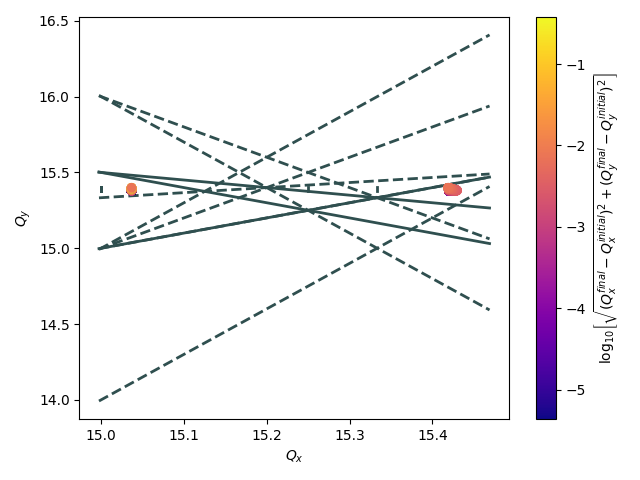

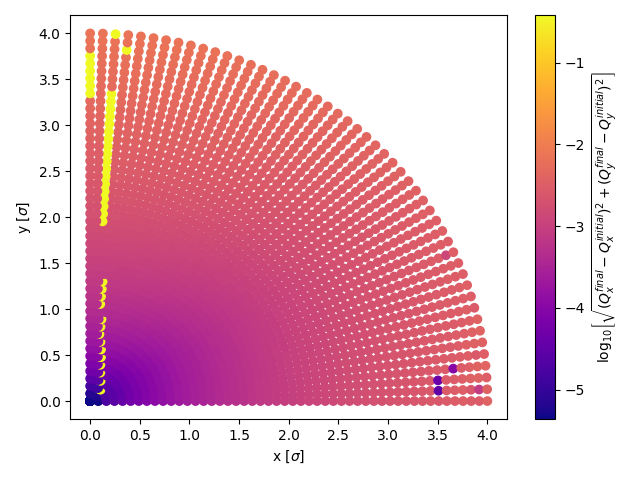

In [ ]:
%matplotlib widget

line=ring
line.config.XTRACK_USE_EXACT_DRIFTS = True
xutil.set_integrator (line)
particle = 'positron'
operation_mode = 'z'
modes = {'z': 45.6e9, # in eV 
        'w': 80e9, # in eV
        'h': 120e9, # in eV 
        't': 182.5e9 # in eV
        }
energy = modes[operation_mode]



context = xo.ContextCpu()         # For CPU
context_tracking = xo.ContextCpu(omp_num_threads='auto') # For CPU with activate multi-core CPU 
# parameters = xutil.log_parameters (None, operation_mode, particle_type=particle, modes=modes)
parameters = {}
line.configure_radiation(model=None)
parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_DA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 1000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':n_emittancex,
    'ini_cond_nemittance_y': n_emittancey,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 2e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'], min_r_y=0, max_r_y=4, num_r_y_points=50, min_theta_x=0, max_theta_x=np.pi/2, 
                            num_theta_x_points=50, cartesian_polar='polar')
print(grid_details)

## Tracking studies
line.configure_radiation(model='mean')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)

Qx_start = xutil.nafflib_tune_calculation(line.record_last_track.x[:, :1000], pq_coordinates=line.record_last_track.px[:, :1000], number_harmonics=1) 
Qy_start = xutil.nafflib_tune_calculation(line.record_last_track.y[:, :1000], pq_coordinates=line.record_last_track.py[:, :1000], number_harmonics=1) 

# Window 2: Last 1000 turns (e.g., from turn 1000 to 2000)
Qx_end = xutil.nafflib_tune_calculation(line.record_last_track.x[:, 1500:2500], pq_coordinates=line.record_last_track.px[:, 1500:2500], number_harmonics=1) 
Qy_end = xutil.nafflib_tune_calculation(line.record_last_track.y[:, 1500:2500], pq_coordinates=line.record_last_track.py[:, 1500:2500], number_harmonics=1) 


my_xpf.tune_diffusion (Qx_start['Q1']+15, Qx_end['Q1']+15, Qy_start['Q1']+15, Qy_end['Q1']+15, initial_conditions_x_axis=grid_details['x_normalized'], initial_conditions_y_axis=grid_details['y_normalized'], xlabel='x [$\sigma$]', ylabel='y [$\sigma$]', resonance_orders=(1,2,3,4), annotate=True, delta_value= None)



In [ ]:
'''fp = line.get_footprint(
    nemitt_x=13000e-6, 
    nemitt_y=12000e-6,
    mode='uniform_action_grid',
    x_norm_range=(0.1, 4),  # Lowered from 6 to 4 sigmas
    y_norm_range=(0.1, 4),  # Lowered from 6 to 4 sigmas
    #n_x_norm=10, 
    #n_y_norm=10,
    freeze_longitudinal=True # Good for 4D/transverse-only footprints
)
fp.qx += 15
fp.qy += 15

# 3. Plotting
fig, ax = plt.subplots(figsize=(8,8))
fp.plot(ax=ax, color='blue', label='Amplitude Footprint')

# Set the limits to the specific integer cell
ax.set_xlim(15.0, 16.0)
ax.set_ylim(15.0, 16.0)

# Optional: Add the Twiss working point for comparison
ax.plot(ring_tw.qx, ring_tw.qy, 'ro', label='Nominal WP')
ax.legend()
'''

"fp = line.get_footprint(\n    nemitt_x=13000e-6, \n    nemitt_y=12000e-6,\n    mode='uniform_action_grid',\n    x_norm_range=(0.1, 4),  # Lowered from 6 to 4 sigmas\n    y_norm_range=(0.1, 4),  # Lowered from 6 to 4 sigmas\n    #n_x_norm=10, \n    #n_y_norm=10,\n    freeze_longitudinal=True # Good for 4D/transverse-only footprints\n)\nfp.qx += 15\nfp.qy += 15\n\n# 3. Plotting\nfig, ax = plt.subplots(figsize=(8,8))\nfp.plot(ax=ax, color='blue', label='Amplitude Footprint')\n\n# Set the limits to the specific integer cell\nax.set_xlim(15.0, 16.0)\nax.set_ylim(15.0, 16.0)\n\n# Optional: Add the Twiss working point for comparison\nax.plot(ring_tw.qx, ring_tw.qy, 'ro', label='Nominal WP')\nax.legend()\n"

In [ ]:
line.configure_radiation(model=None)

parameters['study_parameters'] = {
    'ini_cond_type' : 'grid_MA', # grid_DA, grid_MA, distribution_matched, distribution_injected
    'output_dir' : 'out',
    'number_of_turns' : 2500,
    'number_of_particles' : 1000, 
    'inv1': 0, # np.arange(2)+1,
    'inv2': 0, # np.arange(2,2+3)+1,
    'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
    'ini_cond_nemittance_x':n_emittancex,
    'ini_cond_nemittance_y': n_emittancey,
    'ini_cond_bunch_length': 4.8e-3,
    'ini_cond_energy_spread': 6e-3,
    'ini_cond_energy_offset': None,
    'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
    'covariance_dispertion_free': False
}


## Initial conditions
#particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)
particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])
print(grid_details)

## Tracking studies
line.configure_radiation(model='mean')


## Change context for multy CPU for tracking
line.discard_tracker()
line.build_tracker(_context=context_tracking)


# Use tracking
line.track(particles, num_turns=parameters['study_parameters']['number_of_turns'], turn_by_turn_monitor=True, time=True, with_progress=10) #, freeze_longitudinal=True
particles.sort(interleave_lost_particles=True)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
{'num_theta_x_points': 1, 'num_r_y_points': 31, 'num_delta': 51, 'num_particles': 1581, 'x_normalized': array([ 0.        ,  0.70710678,  1.41421356, ..., 19.79898987,
       20.50609665, 21.21320344]), 'y_normalized': array([ 0.        ,  0.70710678,  1.41421356, ..., 19.79898987,
       20.50609665, 21.21320344]), 'delta_init': array([-0.15, -0.15, -0.15, ...,  0.15,  0.15,  0.15])}
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/2500 [00:00<?, ?it/s]

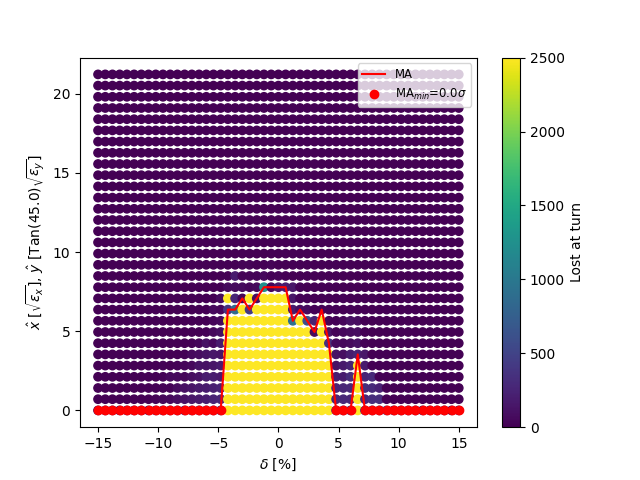

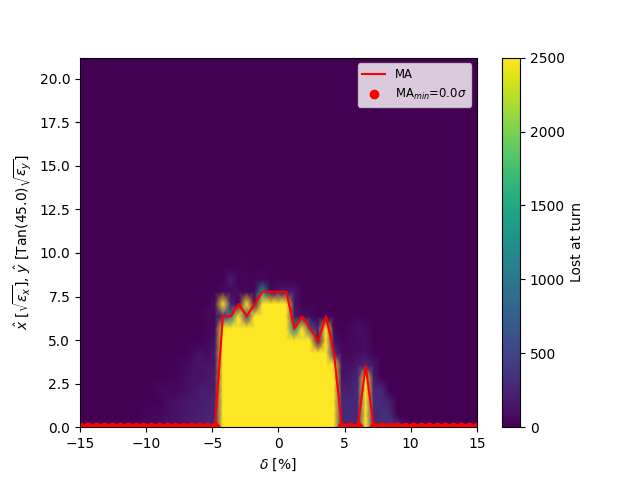

In [ ]:
my_xpf.MA_vs_turns(particles, grid_details['num_r_y_points'], 51, grid_details['x_normalized'], grid_details['y_normalized'], grid_details['delta_init'])

plt.savefig(f"Results/D{design}/C{config}/{mode}/MA_plot_{mode}_WP{current_wp}.png")

In [ ]:

if pdf_run is True:
    pdf.close()

In [ ]:
'''min_DAs=[]

line.discard_tracker()
line.build_tracker(_context=context_tracking)

qx_vals=np.linspace(15.3,15.4,2)
qy_vals=np.linspace(15.3,15.4,2)

for qx_val in qx_vals:
    for qy_val in qy_vals:

        try:
            lo2.matchingWP(qx_val,qy_val)
            parameters['study_parameters'] = {
            'ini_cond_type' : 'grid_DA', # grid_DA, grid_MA, distribution_matched, distribution_injected
            'output_dir' : 'out',
            'number_of_turns' : 100,
            'number_of_particles' : 100, 
            'inv1': 0, # np.arange(2)+1,
            'inv2': 0, # np.arange(2,2+3)+1,
            'start_element' : 'QD1_R1', # 'ca1.1','ip' #'rf400'
            'ini_cond_nemittance_x':13000e-6,
            'ini_cond_nemittance_y': 12000e-6,
            'ini_cond_bunch_length': 4.8e-3,
            'ini_cond_energy_spread': 2e-3,
            'ini_cond_energy_offset': None,
            'new_closed_orbit': None, # {'x': -x_co_inj_marker, 'px': None, 'y': None, 'py': None, 'zeta': None, 'delta': None}
            'covariance_dispertion_free': False
                }
                ## Initial conditions
                #particles = xutil.generate_particle_distribution (line, parameters['study_parameters'], beambeam_strength_used=1, radiation_off=True)

            line.configure_radiation(model=None)
            particles, grid_details = xutil.generate_particle_grid (line, parameters['study_parameters'])

            ## Tracking studies
            line.configure_radiation(model='mean')


            ## Change context for multy CPU for tracking



            # Use tracking
            max_turns = parameters['study_parameters']['number_of_turns']
            line.track(particles, num_turns=max_turns, turn_by_turn_monitor=True, time=True, with_progress=10) 
            particles.sort(interleave_lost_particles=True)

            if isinstance(particles, dict):
                max_turns = np.shape(particles['x'])[1]-1 
                part_at_turn = np.nanmax(particles['at_turn'],axis=1)
            else:
                max_turns = np.max(particles.filter(particles.at_element==0).at_turn) 
                part_at_turn = particles.at_turn
                
            delta_plots=False
            delta_initial=grid_details['delta_init']
            x_norm=grid_details['x_normalized']
            y_norm=grid_details['y_normalized']
            num_r_steps=grid_details['num_r_y_points']
            num_theta_steps=grid_details['num_theta_x_points']
            
            if not delta_plots and np.size(delta_initial) > 1:
                closest_to_zero_delta = delta_initial[(np.abs(delta_initial - 0)).argmin()]
                delta_index = np.where(delta_initial==closest_to_zero_delta)[0]
                x_norm_1d = x_norm[delta_index]
                y_norm_1d = y_norm[delta_index]
                part_at_turn_1d = part_at_turn[delta_index]
            else:
                x_norm_1d = x_norm
                y_norm_1d = y_norm      
                part_at_turn_1d = part_at_turn

            x_norm_2d = x_norm_1d.reshape(num_r_steps, num_theta_steps)
            y_norm_2d = y_norm_1d.reshape(num_r_steps, num_theta_steps)
            part_at_turn_2d = part_at_turn_1d.reshape(num_r_steps, num_theta_steps)
            
            x_DA = np.full(num_theta_steps, np.nan)
            y_DA = np.full(num_theta_steps, np.nan)
            
            for jj in range(num_theta_steps):
                for ii in range(num_r_steps):
                    if part_at_turn_2d[ii,jj] != max_turns:
                        x_DA[jj] = x_norm_2d[ii,jj]
                        y_DA[jj] = y_norm_2d[ii,jj]
                        break

            min_DA = np.nanmin(np.round(np.sqrt(x_DA**2+y_DA**2),1)) 
            where_min_DA = np.where(np.round(np.sqrt(x_DA**2+y_DA**2),1) == min_DA)[0]

            min_DAs.append({
                'qx': qx_val,
                'qy': qy_val,
                'min_da': min_DA
            })
            print(f"WP ({qx_val:.3f}, {qy_val:.3f}) computed successfully. DA: {min_DA}")
            
        except RuntimeError:
            continue'''

        


'min_DAs=[]\n\nline.discard_tracker()\nline.build_tracker(_context=context_tracking)\n\nqx_vals=np.linspace(15.3,15.4,2)\nqy_vals=np.linspace(15.3,15.4,2)\n\nfor qx_val in qx_vals:\n    for qy_val in qy_vals:\n\n        try:\n            lo2.matchingWP(qx_val,qy_val)\n            parameters[\'study_parameters\'] = {\n            \'ini_cond_type\' : \'grid_DA\', # grid_DA, grid_MA, distribution_matched, distribution_injected\n            \'output_dir\' : \'out\',\n            \'number_of_turns\' : 100,\n            \'number_of_particles\' : 100, \n            \'inv1\': 0, # np.arange(2)+1,\n            \'inv2\': 0, # np.arange(2,2+3)+1,\n            \'start_element\' : \'QD1_R1\', # \'ca1.1\',\'ip\' #\'rf400\'\n            \'ini_cond_nemittance_x\':13000e-6,\n            \'ini_cond_nemittance_y\': 12000e-6,\n            \'ini_cond_bunch_length\': 4.8e-3,\n            \'ini_cond_energy_spread\': 2e-3,\n            \'ini_cond_energy_offset\': None,\n            \'new_closed_orbit\': None,

In [ ]:
'''import pandas as pd
%matplotlib widget
df = pd.DataFrame(min_DAs)

# 2. Pivot the data to create a 2D matrix (Qy rows, Qx columns)
# If a specific tune pair crashed or has multiples, 'min' handles it gracefully
heatmap_data = df.pivot_table(index='qy', columns='qx', values='min_da', aggfunc='min')

# Sort index descendingly so higher vertical tunes are at the top of the plot
heatmap_data = heatmap_data.sort_index(ascending=False)

# 3. Define the spatial extent for boundary alignment
qx_centers = heatmap_data.columns.values
qy_centers = heatmap_data.index.values

dx = (qx_centers[1] - qx_centers[0]) / 2.0 if len(qx_centers) > 1 else 0.05
dy = (qy_centers[1] - qy_centers[0]) / 2.0 if len(qy_centers) > 1 else 0.05

extent = [
    qx_centers.min() - dx, qx_centers.max() + dx,
    qy_centers.min() - dy, qy_centers.max() + dy
]

# 4. Generate the plot
fig, ax = plt.subplots(figsize=(9, 8))

# Using 'viridis' or 'jet'. 'inferno' works great for structural DA scans.
cax = ax.imshow(heatmap_data.values, extent=extent, cmap='viridis', aspect='auto')

# Labels and aesthetics
ax.set_xlabel(r'Horizontal Tune ($q_x$)', fontsize=12)
ax.set_ylabel(r'Vertical Tune ($q_y$)', fontsize=12)
ax.set_title('Working Point Scan: Minimum Dynamic Aperture', fontsize=14, pad=15, fontweight='bold')

# Set tick markers directly on your scanned tune steps
ax.set_xticks(qx_vals)
ax.set_yticks(qy_vals)
plt.xticks(rotation=45)

# Colorbar setup
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Minimum DA [$\sigma$]', fontsize=12)

ax.grid(True, which='both', linestyle='--', alpha=0.5, color='grey')

plt.tight_layout()
plt.show()'''

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/tmp/mwatson/ipykernel_2158420/3207943544.py:42: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label(r'Minimum DA [$\sigma$]', fontsize=12)


"import pandas as pd\n%matplotlib widget\ndf = pd.DataFrame(min_DAs)\n\n# 2. Pivot the data to create a 2D matrix (Qy rows, Qx columns)\n# If a specific tune pair crashed or has multiples, 'min' handles it gracefully\nheatmap_data = df.pivot_table(index='qy', columns='qx', values='min_da', aggfunc='min')\n\n# Sort index descendingly so higher vertical tunes are at the top of the plot\nheatmap_data = heatmap_data.sort_index(ascending=False)\n\n# 3. Define the spatial extent for boundary alignment\nqx_centers = heatmap_data.columns.values\nqy_centers = heatmap_data.index.values\n\ndx = (qx_centers[1] - qx_centers[0]) / 2.0 if len(qx_centers) > 1 else 0.05\ndy = (qy_centers[1] - qy_centers[0]) / 2.0 if len(qy_centers) > 1 else 0.05\n\nextent = [\n    qx_centers.min() - dx, qx_centers.max() + dx,\n    qy_centers.min() - dy, qy_centers.max() + dy\n]\n\n# 4. Generate the plot\nfig, ax = plt.subplots(figsize=(9, 8))\n\n# Using 'viridis' or 'jet'. 'inferno' works great for structural DA scans.

In [ ]:
'''context = xo.ContextCpu(omp_num_threads=None)

# %% Simple test of tracking with synchrotron radiation - takes some time
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True)
#ring_tw.plot()
#print( ring_tw.keys() )
print( f' Energy loss per turn from twiss {ring_tw.eneloss_turn:10.2f} and me {U0:10.2f}')
print( 1/ring_tw.damping_constants_turns )
print( 2*E0/ring_tw.eneloss_turn )

npts = 200
epsx, epsy, epsl = 1.0e-7, 1.0e-7, 1.0e-4  # starting with somewhat large emittances
betxin, alfxin  = ring_tw.betx[0], ring_tw.alfx[0] 
xin, pxin       = ring_tw.x[0], ring_tw.px[0]
dxin, dpxin     = ring_tw.dx[0], ring_tw.dpx[0]
betyin, alfyin  = ring_tw.bety[0], ring_tw.alfy[0] 
yin, pyin       = ring_tw.y[0], ring_tw.py[0]   # should be zero for perfect case
#epsx, epsl      = 2.0*ring_tw.eq_gemitt_x, 2.0*ring_tw.eq_gemitt_zeta
betlin          = ring_tw.bets0
zetain, deltain = ring_tw.zeta[0], ring_tw.delta[0]
print( f'At reference location: D ={dxin:7.4f} m, Dp ={dpxin:7.4f},' +
       f' betx ={betxin:7.4f} m, alfx ={alfxin:7.4f},' + 
       f' betl ={betlin:7.4f} m ')

normat = np.array([
    [(epsx*betxin)**.5,         0,                 0,  0, 0, dxin*(epsl/betlin)**.5],
    [-alfxin*(epsx/betxin)**.5, (epsx/betxin)**.5, 0,  0, 0, dpxin*(epsl/betlin)**.5],
    [0,  0,  (epsx*betyin)**.5,         0,                 0, 0],
    [0,  0,  -alfyin*(epsx/betyin)**.5, (epsx/betyin)**.5, 0, 0],
    [0, 0, 0, 0, (epsl*betlin)**.5, 0                ],
    [0, 0, 0, 0, 0,                 (epsl/betlin)**.5]               
    ])

parts = np.array([
     [xin, pxin, yin, pyin, zetain, deltain] + normat@np.random.randn(6) 
         for ind in range(npts) ]).T
# quit()
p2 = xt.Particles(kinetic_energy0 = 2860.e6, mass0 = xt.ELECTRON_MASS_EV,
                  x    = parts[0], px   = parts[1],
                  y    = parts[2], py   = parts[3],
                  zeta = parts[4], delta = parts[5] )
ring.configure_radiation(model='quantum')
ring.track( p2, num_turns = 6100, turn_by_turn_monitor = True,
            with_progress = True )

data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]
#trnplt = range( len(data.x.T) ) # superimpose all turns, rendering is slowish
fig = plt.figure( figsize=(14., 4.) )
fig.suptitle( f'Phase Space Plots - particle survival {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
ax = fig.subplots(1, 3)
fig.subplots_adjust( wspace=0.4 )
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel("x' (mrad)")
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel("y' (mrad)")
ax[2].set_xlabel('z (mm)')
ax[2].set_ylabel(r'rel. mom. offset ($10^{-3}$)')
for ind in range( len(trnplt) ):  # data.x.T[ind] is nparray (behaviour of multiplication)!
   print( f' ==> Plotting turn"{trnplt[ind]:5d}')
   ax[0].scatter( 1000*(data.x.T[trnplt[ind]] - 1.*ring_tw.dx[0]*data.delta.T[trnplt[ind]]), 
            1000*(data.px.T[trnplt[ind]] - 1.*ring_tw.dpx[0]*data.delta.T[trnplt[ind]]),
            s=.4, c = f'C{ind:1d}')
   ax[1].scatter( 1000*(data.y.T[trnplt[ind]]), 1000*(data.py.T[trnplt[ind]]), 
            s=.2, c = f'C{ind:1d}' )
   ax[2].scatter(1000*data.zeta.T[trnplt[ind]], 1000*data.delta.T[trnplt[ind]], 
            s=.2, color=f'C{ind:1d}' )

print( [pdr['RFCav_1'].lag, pdr['RFCav_1'].voltage] )

print( f' Particle survival: {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
plt.savefig(f'config_D{n}/Particle_survival_{n}.png')'''

'context = xo.ContextCpu(omp_num_threads=None)\n\n# %% Simple test of tracking with synchrotron radiation - takes some time\nring.configure_radiation(model=\'mean\')\nring_tw=ring.twiss(method=\'6d\', radiation_integrals=True, eneloss_and_damping=True)\n#ring_tw.plot()\n#print( ring_tw.keys() )\nprint( f\' Energy loss per turn from twiss {ring_tw.eneloss_turn:10.2f} and me {U0:10.2f}\')\nprint( 1/ring_tw.damping_constants_turns )\nprint( 2*E0/ring_tw.eneloss_turn )\n\nnpts = 200\nepsx, epsy, epsl = 1.0e-7, 1.0e-7, 1.0e-4  # starting with somewhat large emittances\nbetxin, alfxin  = ring_tw.betx[0], ring_tw.alfx[0] \nxin, pxin       = ring_tw.x[0], ring_tw.px[0]\ndxin, dpxin     = ring_tw.dx[0], ring_tw.dpx[0]\nbetyin, alfyin  = ring_tw.bety[0], ring_tw.alfy[0] \nyin, pyin       = ring_tw.y[0], ring_tw.py[0]   # should be zero for perfect case\n#epsx, epsl      = 2.0*ring_tw.eq_gemitt_x, 2.0*ring_tw.eq_gemitt_zeta\nbetlin          = ring_tw.bets0\nzetain, deltain = ring_tw.zeta[0], ring